In [38]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import time
import math
import copy
import matplotlib.pyplot as plt
import numpy as np
import os 
from tqdm import tqdm

现在进行$ResNet$变成$ConvNeXt$的过程

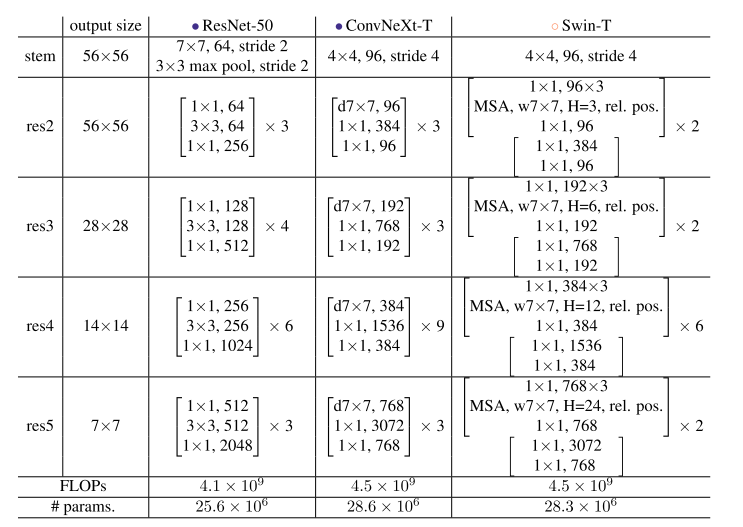

首先建立$ResNet$的基本块，这里是用$ResNet-50$来模拟的

In [25]:
class ResNet_Block_50(nn.Module):
    '''ResNet-50的基本块'''
    def __init__(self , in_channels , out_channels, stride=1):
        super(ResNet_Block_50 , self).__init__()
        expansion = 4
        self.layer = nn.Sequential(
            nn.Conv2d(kernel_size=1 , 
                      stride= 1 , 
                      padding= 0 , 
                      in_channels = in_channels,
                      out_channels=out_channels
                    ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace = True),

            nn.Conv2d(
                kernel_size=3,
                stride=stride,
                padding=1,
                in_channels=out_channels,
                out_channels=out_channels
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace = True),

            nn.Conv2d(
                kernel_size=1,
                stride=1,
                padding=0,
                in_channels=out_channels,
                out_channels=out_channels * expansion
            ),
            nn.BatchNorm2d(out_channels * expansion ),
            nn.ReLU(inplace = True)
        )
        self.downsample = None
        if stride != 1 or in_channels != out_channels * expansion:
            self.downsample = nn.Sequential(
                nn.Conv2d(
                    kernel_size = 1 , 
                    stride = stride ,
                    padding = 0 ,
                    in_channels = in_channels ,
                    out_channels = out_channels * expansion ,
                    bias=False
                    ),
                nn.BatchNorm2d(out_channels * expansion )
                )
            
    def forward(self , x):
        identity = x
        out = self.layer(x)
        if self.downsample is not None:
            identity = self.downsample(x)
        out = out + identity
        out = F.relu(out)
        return out
    
models = ResNet_Block_50(in_channels=3 , out_channels=64 ,stride = 1)
# x = torch.randn(1 , 3 , 4 , 4)
# out = models(x)
# x , out ,x.size(),out.size()

然后建立基本的$ResNet-50$网络架构

In [26]:
class ResNet_50(nn.Module):
    '''ResNet-50的网络架构 '''
    def __init__(self , num_classes = 1000 , in_channels = 3):
        super(ResNet_50 , self).__init__()
        self.pre_layer = nn.Sequential(
            # nn.Conv2d(
            #     kernel_size = 7,
            #     stride= 2 ,
            #     padding = 3,#(7-1)/2
            #     in_channels = in_channels,
            #     out_channels = 64
            # ),
            nn.Conv2d(
                kernel_size = 1,
                stride= 1 ,
                padding = 0,
                in_channels = in_channels,
                out_channels = 64
            ),#专门为了CIFAR10数据集修改的
            nn.BatchNorm2d(64),
            nn.ReLU(inplace =True),
            nn.MaxPool2d(kernel_size = 3 , stride = 2 , padding = 1)
        )
        self.layer1 = nn.Sequential(
            ResNet_Block_50(in_channels=64 , out_channels=64 , stride=1),
            ResNet_Block_50(in_channels=256 , out_channels=64 , stride=1),
            ResNet_Block_50(in_channels=256 , out_channels=64 , stride=1)
        )

        self.layer2 = nn.Sequential(
            ResNet_Block_50(in_channels=256 , out_channels=128 , stride=2),
            ResNet_Block_50(in_channels=512 , out_channels=128 , stride=1),
            ResNet_Block_50(in_channels=512 , out_channels=128 , stride=1),
            ResNet_Block_50(in_channels=512 , out_channels=128 , stride=1)
        )

        self.layer3 = nn.Sequential(
            ResNet_Block_50(in_channels=512 , out_channels=256 , stride=2),
            ResNet_Block_50(in_channels=1024 , out_channels=256 , stride=1),
            ResNet_Block_50(in_channels=1024 , out_channels=256 , stride=1),
            ResNet_Block_50(in_channels=1024 , out_channels=256 , stride=1),
            ResNet_Block_50(in_channels=1024 , out_channels=256 , stride=1),
            ResNet_Block_50(in_channels=1024 , out_channels=256 , stride=1)
        )

        self.layer4 = nn.Sequential(
            ResNet_Block_50(in_channels=1024 , out_channels=512 , stride=2),
            ResNet_Block_50(in_channels=2048 , out_channels=512 , stride=1),
            ResNet_Block_50(in_channels=2048 , out_channels=512 , stride=1)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(2048 , num_classes)

    def forward(self , x):
        x = self.pre_layer(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x , 1)
        x = self.fc(x)
        return x
    
models = ResNet_50(in_channels=3 , num_classes=10)
x = torch.randn(1 , 3 , 224 , 224)
out = models(x)
x , out ,x.size(),out.size()
        

(tensor([[[[-0.3362,  0.4774,  0.5585,  ...,  0.7481,  0.0587,  1.6041],
           [-1.3209, -0.8610, -0.4466,  ...,  1.2022,  0.9617, -1.7066],
           [ 0.8083, -2.9834, -1.6615,  ..., -0.3461,  1.1870,  0.6919],
           ...,
           [-0.1905, -1.3849,  0.1473,  ...,  0.0178,  1.0007,  0.1290],
           [ 1.4564,  0.0737,  0.6582,  ..., -0.2793, -0.6097, -0.9937],
           [-2.2650, -0.6178,  0.0759,  ...,  2.3385,  0.0082, -0.0502]],
 
          [[-2.3673, -0.6116,  1.2721,  ...,  0.9530, -1.1535,  0.5402],
           [-0.2834, -0.5959,  1.8897,  ..., -0.9864,  1.3804,  0.2500],
           [-1.1621, -0.7187, -1.9113,  ..., -1.3202, -1.6238,  0.4029],
           ...,
           [-1.4192,  0.2268,  1.2469,  ...,  0.3649, -0.2439, -1.3773],
           [ 0.2962, -0.8747,  2.9862,  ...,  1.2609,  1.3295,  0.7762],
           [-2.8796,  0.0466,  1.2540,  ..., -1.4402,  0.0302,  0.8397]],
 
          [[-0.6383, -0.3926, -0.0818,  ...,  2.1032, -1.4730, -0.0986],
           [ 

##### 现在根据$ConvNeXt$对$ResNet$进行修改
1. 对于每一层卷积的次数进行调整从（3：4：6：3） 变成 （3：3：9：3）
2. 在网络前面的下采样部分进行调整从（7x7卷积加上3x3的最大池化）变成（单个4x4卷积步长为4）
3. 将原本的深度卷积（ResNet中是3x3卷积）变成了（深度可分离卷积）。
4. 将原本的正常瓶颈结构（1x1降低维度后升高维度）变成了倒瓶颈（1x1升高维度后降低维度）
5. 上拉原本的深度卷积，将（原本位于1x1后面的深度卷积）变成了（位于1x1前面的深度卷积）
6. 适当增加深度卷积的卷积核大小从原本的（3x3）变成（7×7）
7. 用（原本的ReLU激活函数）变成了（现在的GELU激活函数）
8. 减少激活函数以及归一层的使用。
9. 将原本的BN归一层变成了现在的LN归一层
10. 使用单独的下采样操作

现在开始根据上面的代码以及相对应的版本进行修改

首先就是搞一个深度可分离网络模块

In [27]:
class DepthWiseConv(nn.Module):
    '''A深度可分离卷积'''
    def __init__(self , in_channels , kernel_size , stride = 1 , padding = 0):
        super(DepthWiseConv , self).__init__()
        self.depthwise_conv = nn.Conv2d(
            in_channels = in_channels ,
            out_channels = in_channels ,
            kernel_size = kernel_size ,
            stride = stride ,
            padding = padding ,
            groups = in_channels,
            bias= False
        )
        self.pointwise_conv = nn.Conv2d(
            in_channels = in_channels ,
            out_channels = in_channels ,
            kernel_size = 1 ,
            stride = 1 ,
            padding = 0,
            bias = False
        )
    def forward(self , x):
        out = self.depthwise_conv(x)
        out = self.pointwise_conv(out)
        return out

然后就是基本的$ConvNeXt$模块

In [29]:
class ConvNeXt_Block(nn.Module):
    # 第8个改进，整体减少归一化以及激活函数的使用
    '''ConvNeXt的基本块'''
    def __init__(self , in_channels , stride=1 , feature_size = 224):
        super(ConvNeXt_Block , self).__init__()
        expansion = 4
        # 第3个改进，使用深度可分离卷积
        # 第4个改进，将原本的正常瓶颈结构变成倒瓶颈结构
        # 第5个改进，上拉原本的深度卷积
        # 第6个改进，适当增大卷积核的大小
        self.layer1 = DepthWiseConv(in_channels , kernel_size=7 , stride=1 , padding=3)
        # 第9个改进，用LN
        self.layer2 = nn.LayerNorm(in_channels)

        self.layer3 = nn.Conv2d(in_channels , in_channels * expansion , kernel_size= 1 , padding= 0 , bias=False)
        # 第7个改进，使用GELU激活函数
        self.gelu = nn.GELU()

        self.layer4 = nn.Conv2d(in_channels * expansion , in_channels , kernel_size=1 , padding=0 , bias = False)

    def forward(self , x):
        identity = x
        out = self.layer1(x)
        out = out.permute(0, 2, 3, 1)
        out = self.layer2(out)
        out = out.permute(0, 3, 1, 2)
        out = self.layer3(out)
        out = self.gelu(out)
        out = self.layer4(out)
        out = out + x
        return out
x = torch.randn(4 , 3 , 224 , 224)
models = ConvNeXt_Block(3 , stride=1 , feature_size=224)
out = models(x)
out.size()

torch.Size([4, 3, 224, 224])

再来就是建立ConvNeXt网络了
首先肯定是基本的下采样层啦

In [30]:
class Downsample_Layer(nn.Module):
    # 第10个改进使用单独的下采样操作
    def __init__(self, in_dims, out_dims):
        super().__init__()
        self.downsample = nn.Sequential(
            nn.LayerNorm(in_dims), 
        )
        self.conv = nn.Conv2d(in_dims, out_dims, kernel_size=2, stride=2)

    def forward(self, x):
        # 1. 调整维度以适配 LayerNorm: (N, C, H, W) -> (N, H, W, C)
        x = x.permute(0, 2, 3, 1)
        x = self.downsample[0](x)
        # 2. 转换回卷积格式: (N, H, W, C) -> (N, C, H, W)
        x = x.permute(0, 3, 1, 2)
        # 3. 执行下采样卷积
        x = self.conv(x)
        return x

In [ ]:
class ConvNeXt_Net(nn.Module):
    def __init__(self , in_channels = 96 , num_classes = 1000):
        # 第1个改进层数的比例更改3:3:9:3
        super(ConvNeXt_Net, self).__init__()
        # 第2个改进使用4x4卷积替换掉原来的卷积加上池化处理
        # self.pre_downsample = nn.Conv2d(kernel_size=4 , stride = 4 , in_channels = 3 , out_channels = 96 , padding = 1)
        # 基于CIFAR-10数据集的图片大小32x32，所以这里改成2x2卷积替换掉原来的卷积加上池化处理
        self.pre_downsample = nn.Conv2d(kernel_size=2 , stride = 2 , in_channels = 3 , out_channels = 96 , padding = 0)
        self.layer1 = nn.Sequential(
            ConvNeXt_Block(in_channels , stride = 1 , feature_size = 224),
            ConvNeXt_Block(in_channels , stride = 1 , feature_size = 224),
            ConvNeXt_Block(in_channels , stride = 1 , feature_size = 224)
        )
        self.downsample1 = Downsample_Layer(in_dims=in_channels, out_dims=in_channels * 2)
        self.layer2 = nn.Sequential(
            ConvNeXt_Block(in_channels * 2 , stride = 1 , feature_size = 112),
            ConvNeXt_Block(in_channels * 2 , stride = 1 , feature_size = 112),
            ConvNeXt_Block(in_channels * 2 , stride = 1 , feature_size = 112)
        )
        self.downsample2 = Downsample_Layer(in_dims=in_channels * 2, out_dims=in_channels * 4)
        self.layer3 = nn.Sequential(
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56),
            ConvNeXt_Block(in_channels * 4 , stride = 1 , feature_size = 56)
        )
        self.downsample3 = Downsample_Layer(in_dims=in_channels * 4, out_dims=in_channels * 8)
        self.layer4 = nn.Sequential(
            ConvNeXt_Block(in_channels * 8 , stride = 1 , feature_size = 28),
            ConvNeXt_Block(in_channels * 8 , stride = 1 , feature_size = 28),
            ConvNeXt_Block(in_channels * 8 , stride = 1 , feature_size = 28)
        )

        self.layer5 = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels * 8, num_classes)
        )
    def forward(self , x):
        out = self.pre_downsample(x)
        out = self.layer1(out)
        out = self.downsample1(out)
        out = self.layer2(out)
        out = self.downsample2(out)
        out = self.layer3(out)
        out = self.downsample3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        return out 



torch.Size([2, 10])


下面就是基本的训练代码了也没啥好说的了

In [36]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torchvision 
from torchvision import transforms, datasets
import torch.optim as optim
import time
from tqdm import tqdm
import os
from torch.cuda.amp import autocast, GradScaler

def train_model():
    # 数据预处理 (使用32x32原始尺寸)
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    
    test_transform = transforms.Compose([
        # transforms.RandomCrop(32, padding=4),
        # transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])

    # 加载数据集
    train_dataset = datasets.CIFAR10(root='E:\\mastercode\\data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='E:\\mastercode\\data', train=False, download=True, transform=test_transform)

    # 数据加载器
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
    
    # 设备配置
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")

    # 初始化模型
    model = ConvNeXt_Net(in_channels=96 , num_classes=10).to(device) # 有点失误了
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 训练参数
    epochs = 20
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    # 训练循环
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        # 带进度条的训练
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [训练]')
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # 统计
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # 更新进度条
            pbar.set_postfix(loss=loss.item(), acc=100*correct/total)
        
        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        
        # 验证阶段
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        
        # 带进度条的验证
        pbar = tqdm(test_loader, desc=f'Epoch {epoch+1}/{epochs} [验证]')
        with torch.no_grad():
            for images, labels in pbar:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                pbar.set_postfix(loss=loss.item(), acc=100*correct/total)
        
        test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')

    # 3. 绘制图片
    plt.figure(figsize=(12, 5))
    
    # 损失曲线
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, 'b-', label='Training Loss')
    plt.plot(test_losses, 'r-', label='Testing Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('LOSS')
    plt.legend()
    
    # 准确率曲线
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, 'b-', label='Training Accuracy')
    plt.plot(test_accs, 'r-', label='Testing Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title('ACCURACY')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_results.png')
    plt.show()
    
    return model

# if __name__ == "__main__":
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     trained_model = train_model()

In [37]:
if __name__ == "__main__":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trained_model = train_model()


Files already downloaded and verified
Files already downloaded and verified
使用设备: cuda


Epoch 1/20 [验证]: 100%|██████████| 157/157 [00:09<00:00, 17.44it/s, acc=35.9, loss=1.52]


Epoch 1/20, Train Loss: 2.1779, Train Acc: 24.38%, Test Loss: 1.7177, Test Acc: 35.90%


Epoch 2/20 [验证]: 100%|██████████| 157/157 [00:09<00:00, 17.01it/s, acc=44.8, loss=1.54]


Epoch 2/20, Train Loss: 1.6488, Train Acc: 38.49%, Test Loss: 1.5230, Test Acc: 44.83%


...

Epoch 3/20, Train Loss: 1.4703, Train Acc: 45.96%, Test Loss: 1.3590, Test Acc: 51.68%


Epoch 4/20 [验证]: 100%|██████████| 157/157 [00:08<00:00, 17.94it/s, acc=56.1, loss=1.11] 


Epoch 4/20, Train Loss: 1.3985, Train Acc: 49.29%, Test Loss: 1.1996, Test Acc: 56.12%


Epoch 5/20 [训练]:  34%|███▎      | 262/782 [00:55<01:50,  4.73it/s, acc=54, loss=1.16]  


KeyboardInterrupt: 

感觉测试了一下，还没有ResNet的效果好，可能是数据集有问题吧